In [ ]:
import pandas as pd
from sklearn.datasets import load_boston
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Step 1: Load and Prepare the Dataset
boston = load_boston()
data = pd.DataFrame(boston.data, columns=boston.feature_names)
data['MEDV'] = boston.target  # MEDV is the target variable (Median value of owner-occupied homes)

# Display the first few rows of the dataset
print("Dataset:")
print(data.head())

# Step 2: Define features (X) and target (y)
X = data.drop('MEDV', axis=1)
y = data['MEDV']

# Step 3: Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("\nTraining and Testing Sets:")
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

# Step 4: Initialize the linear regression model
model = LinearRegression()

# Step 5: Train the model
model.fit(X_train, y_train)

# Display the coefficients and intercept
print("\nModel Coefficients:")
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

# Step 6: Make predictions on the test set
y_pred = model.predict(X_test)

# Step 7: Calculate evaluation metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nModel Evaluation:")
print("Mean Squared Error (MSE):", mse)
print("R-squared (R²) Score:", r2)

# Step 8: Example prediction
example_data = X_test.iloc[0].values.reshape(1, -1)
predicted_value = model.predict(example_data)

print("\nExample Prediction:")
print("Input features:", X_test.iloc[0])
print("Predicted MEDV:", predicted_value[0])
print("Actual MEDV:", y_test.iloc[0])


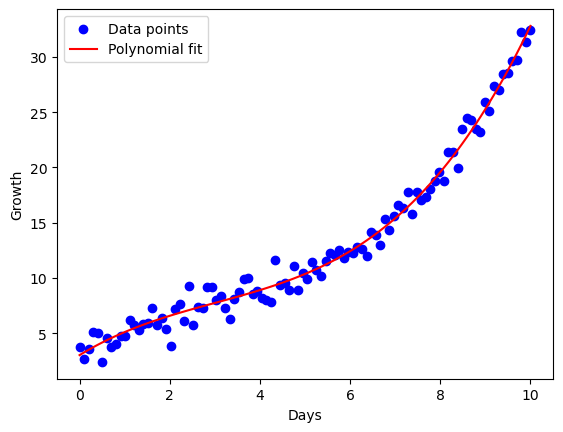

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

# Simulate plant growth data
np.random.seed(0)
days = np.linspace(0, 10, 100)
growth = 2 + 3 * days - 0.5 * days**2 + 0.05 * days**3 + np.random.normal(0, 1, days.shape)

days = days[:, np.newaxis]

# Fit polynomial regression model
degree = 3
polynomial_features = PolynomialFeatures(degree=degree)
linear_regression = LinearRegression()
model = make_pipeline(polynomial_features, linear_regression)
model.fit(days, growth)

# Predict and plot
days_pred = np.linspace(0, 10, 100).reshape(-1, 1)
growth_pred = model.predict(days_pred)

plt.scatter(days, growth, color='blue', label='Data points')
plt.plot(days_pred, growth_pred, color='red', label='Polynomial fit')
plt.xlabel('Days')
plt.ylabel('Growth')
plt.legend()
plt.show()


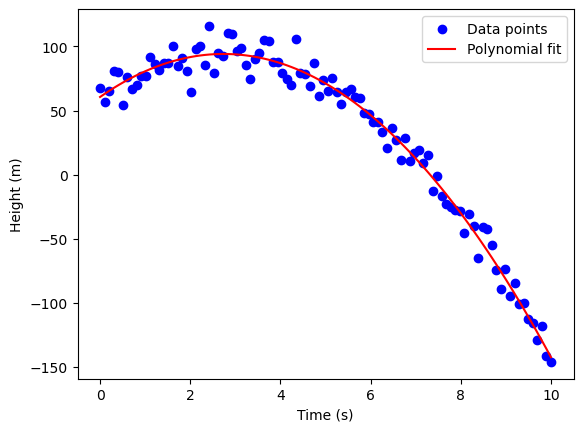

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

# Simulate ball trajectory data
np.random.seed(0)
time = np.linspace(0, 10, 100)
height = 50 + 30 * time - 5 * time**2 + np.random.normal(0, 10, time.shape)

time = time[:, np.newaxis]

# Fit polynomial regression model
degree = 2
polynomial_features = PolynomialFeatures(degree=degree)
linear_regression = LinearRegression()
model = make_pipeline(polynomial_features, linear_regression)
model.fit(time, height)

# Predict and plot
time_pred = np.linspace(0, 10, 100).reshape(-1, 1)
height_pred = model.predict(time_pred)

plt.scatter(time, height, color='blue', label='Data points')
plt.plot(time_pred, height_pred, color='red', label='Polynomial fit')
plt.xlabel('Time (s)')
plt.ylabel('Height (m)')
plt.legend()
plt.show()


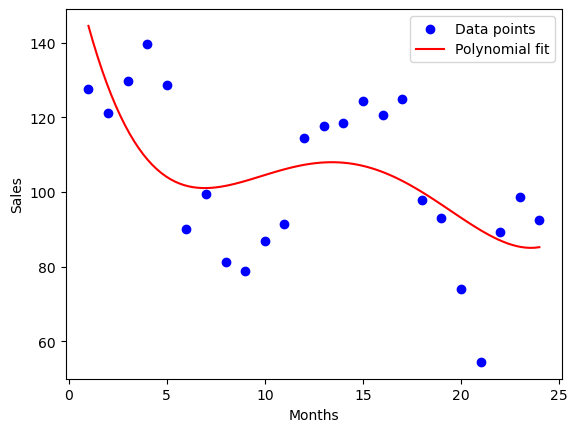

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

# Simulate seasonal sales data
np.random.seed(0)
months = np.arange(1, 25)
sales = 100 + 20 * np.sin(months * 2 * np.pi / 12) + np.random.normal(0, 10, months.shape)

months = months[:, np.newaxis]

# Fit polynomial regression model
degree = 4
polynomial_features = PolynomialFeatures(degree=degree)
linear_regression = LinearRegression()
model = make_pipeline(polynomial_features, linear_regression)
model.fit(months, sales)

# Predict and plot
months_pred = np.linspace(1, 24, 100).reshape(-1, 1)
sales_pred = model.predict(months_pred)

plt.scatter(months, sales, color='blue', label='Data points')
plt.plot(months_pred, sales_pred, color='red', label='Polynomial fit')
plt.xlabel('Months')
plt.ylabel('Sales')
plt.legend()
plt.show()


In [8]:
# Data Normalization vs. Standardization
# Normalization and standardization are two common techniques used to scale
# numerical data in the preprocessing stage of machine learning. Both methods
# aim to adjust the values of numerical features to ensure that the features contribute# # 
# equally to the learning process. However, they do so in different ways.


# Normalization
# Normalization scales the data to a fixed range, typically between 0 and 1, or -1 and 1.
# This technique is also known as min-max scaling.

# Standardization
# Standardization transforms the data to have a mean of zero and a standard deviation of one.
# This technique is also known as z-score normalization.


In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Load the dataset
# Replace 'your_dataset.csv' with the path to your dataset
df = pd.read_csv('your_dataset.csv')

# Display the first few rows of the dataset
print("Original Dataset:")
print(df.head())

# Separate numerical columns (excluding 'Gender' and 'Workout_Type' as they are categorical)
numerical_columns = df.select_dtypes(include=['float64', 'int64']).columns

# Standardization
scaler_standard = StandardScaler()
df_standardized = df.copy()
df_standardized[numerical_columns] = scaler_standard.fit_transform(df[numerical_columns])

# Normalization
scaler_normalize = MinMaxScaler()
df_normalized = df.copy()
df_normalized[numerical_columns] = scaler_normalize.fit_transform(df[numerical_columns])

# Display the first few rows of the standardized data
print("\nStandardized Dataset:")
print(df_standardized.head())

# Display the first few rows of the normalized data
print("\nNormalized Dataset:")
print(df_normalized.head())


In [ ]:
# Categorical Data: If you need to encode categorical data (like Gender and Workout_Type),
# consider using one-hot encoding before scaling.

# One-hot encoding is a technique used to convert categorical data into a numerical format 
# that can be used in machine learning models. It transforms each category value into a new 
# binary column. Each column represents a category, and a row with a particular category will
# have a 1 in that column and 0s in all other columns

In [ ]:
import pandas as pd

# Sample DataFrame
data = {
    'Age': [25, 30, 22, 40],
    'Gender': ['Male', 'Female', 'Female', 'Male'],
    'Weight': [70, 60, 55, 80]
}
df = pd.DataFrame(data)

# Display the original DataFrame
print("Original DataFrame:")
print(df)

# Apply one-hot encoding to the 'Gender' column
df_encoded = pd.get_dummies(df, columns=['Gender'], drop_first=True)

# Display the DataFrame after one-hot encoding
print("\nDataFrame after One-Hot Encoding:")
print(df_encoded)


In [ ]:
# Handling a categorical column with many unique values 
# (like a "Country" column with around 200 unique countries) can be challenging,
# but there are several techniques to efficiently manage and encode this data for machine 
# learning models.

In [ ]:
Techniques for Handling High Cardinality Categorical Data
One-Hot Encoding:

Converts each unique category value into a new binary column.

Drawback: With many unique values, it can create a very large number of columns, leading to a high-dimensional and sparse dataset.
Label Encoding:
Assigns each unique category value a unique integer.

Drawback: Can introduce unintended ordinal relationships between categories.
Frequency Encoding:
Replaces each category with its frequency (or count) in the dataset.
Benefit: Reduces dimensionality and retains some information about the category distribution.

Target Encoding:
Replaces each category with the mean of the target variable for that category.
Benefit: Can be more predictive but risks overfitting, especially with small datasets.

Embedding:
Uses techniques like word embeddings to represent categories in a lower-dimensional space.
Benefit: Useful in deep learning models and when there are many categories.

In [ ]:
# When you have outlier data in your dataset, it’s crucial to handle and clean this data to
# improve the performance and accuracy of your regression models. Outliers can distort 
# statistical analyses and model predictions, leading to unreliable results. Here are some 
# common methods to detect and remove outliers:

In [ ]:
# Methods to Handle Outliers
# Visual Inspection:

# Boxplots: Provide a visual representation of the distribution of data and help
# identify outliers.
# Scatter plots: Useful for bivariate data to spot outliers.

# Statistical Methods:
# Z-Score: Measures the number of standard deviations a data point is from the mean. 
# Common threshold: |z| > 3.
# IQR (Interquartile Range): Calculates the range between the first quartile (25th percentile) and the third quartile (75th percentile). 
# Outliers are typically defined as data points outside 1.5 * IQR.

# Machine Learning Algorithms:
# Isolation Forest: Anomaly detection method that isolates observations by randomly
# selecting a feature and a split value.
# DBSCAN (Density-Based Spatial Clustering of Applications with Noise):
# Clustering method that can identify outliers as noise points.

In [ ]:
from scipy import stats

# Calculate Z-Scores
z_scores = stats.zscore(df[['Age', 'Weight', 'Height']])
abs_z_scores = abs(z_scores)

# Threshold for identifying outliers
threshold = 3
outliers = (abs_z_scores > threshold).any(axis=1)
df_no_outliers = df[~outliers]

print("\nDataFrame after removing outliers using Z-Score:")
print(df_no_outliers)


In [ ]:
# Calculate IQR
Q1 = df[['Age', 'Weight', 'Height']].quantile(0.25)
Q3 = df[['Age', 'Weight', 'Height']].quantile(0.75)
IQR = Q3 - Q1

# Filter out outliers
df_no_outliers_iqr = df[~((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).any(axis=1)]

print("\nDataFrame after removing outliers using IQR:")
print(df_no_outliers_iqr)


In [ ]:
# Regularization
# Regularization is a technique used to prevent overfitting in machine learning models
# by adding a penalty to the model's complexity. Overfitting occurs when a model learns
# the noise in the training data rather than the underlying pattern, which leads to poor
# generalization to new data. Regularization methods add a regularization term to the loss
# function, which discourages overly complex models.


# Ridge Regression (L2 Regularization): Adds a penalty equal to the square of the magnitude of coefficients.
# Lasso Regression (L1 Regularization): Adds a penalty equal to the absolute value of the magnitude of coefficients.
# Elastic Net: Combines both L1 and L2 regularization.
# Regularization helps in preventing overfitting, especially when dealing with high-dimensional data.

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_regression

# Generate sample data
X, y = make_regression(n_samples=100, n_features=2, noise=0.1, random_state=42)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Apply Ridge Regression
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
ridge_pred = ridge.predict(X_test)

# Print coefficients and intercept
print("Ridge Coefficients:", ridge.coef_)
print("Ridge Intercept:", ridge.intercept_)
